# CellorNuc Starter Quiz

Xiuyuan Lu

## Setup and Method Overview

### Setup

In [37]:
%matplotlib inline
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

ROOT = Path("..") if Path("../scanpyplus").is_dir() else Path(".")
sys.path.insert(0, str(ROOT.resolve()))
from scanpyplus import Scanpyplus

sc.settings.set_figure_params(dpi=110, facecolor="white", figsize=(5, 5))
sns.set_theme(style="whitegrid", context="notebook")

### Method Overview

(my notes for understanding of math of the model; if you are not interested, feel free to skip this section and see my answers to quiz questions )

Before actually starting the quiz, I investigated into the source code (with the help of Codex) and extracted the model (**BetaBinomial + EM**) of CellorNucEM.  

**Notation**

* $x_i, y_i, m_i$: for droplet $i$, $x_i$ = sc signature counts, $y_i$ = sn signature counts,and $m_i = x_i + y_i$ is the modality count;
* `sc_frac` = $\frac{x_i}{m_i}$ is a raw observed fraction (not the probability given by the model) that indicates the proportion of sc signature of a droplet; 
* $p_k$: for each mixture component $k$ (namely cell and nucleus in our case) with $(\alpha_k, \beta_k)$, the beta distribution mean is $p_k = \frac{\alpha_k}{\alpha_k + \beta_k}$, which is the component mean $p$ to be analyzed in Q3; 
* $p_{\text{cell}}$: a posterior probability different from raw observation `sc_frac`; $p_{\text{cell}, i} = P(z_i=\text{cell-like}\mid x_i, m_i, \text{fitted model})$ expresses how strongly the fitted mixture model interprets that observation as belonging to the cell-like component;
* for compent $k$, $X_i \mid m_i, Z_i = k \sim \text{BetaBinomial}(m_i, \alpha_k, \beta_k)$



## Q1. Run the classifier on the mixed dataset A (cells + nuclei)

**Download the dataset A and run CellorNucEM on the mixed dataset A.**

In [38]:
sc_genes, sn_genes = Scanpyplus.LoadGeneSignatures()
mixed = sc.read_h5ad(ROOT / "data" / "mixed_mBDRC_5pCells_multiomeNuclei_full.h5ad")
print(f"sc signature ({len(sc_genes)} genes): {sc_genes}")
print(f"sn signature ({len(sn_genes)} genes): {sn_genes}")

sc signature (10 genes): ['EEF1A1', 'TPT1', 'FTH1', 'FTL', 'SERF2', 'ATP5F1E', 'GAPDH', 'UBA52', 'COX7C', 'MIF']
sn signature (10 genes): ['FTX', 'AGAP1', 'GMDS-DT', 'PARD3', 'WWOX', 'MAGI2', 'PKHD1', 'NHS', 'AC098829.1', 'DPP6']


### 1a

**Are there any cell droplets called Typical Nucleus (SN), or any nucleus droplets called Typical Cell (SC)? How well does the signature work on this independent dataset?** 

In [39]:
print("Known modality counts:")
print(mixed.obs["suspension_type"].value_counts())
print("\nSequencing assay values:")
print(mixed.obs["assay"].value_counts())

q1 = Scanpyplus.CellorNucEM(
    mixed,
    sc_genes,
    sn_genes,
    layer="counts",
    assay_col="suspension_type",
    sc_label="cell",
    sn_label="nucleus",
    min_counts=10,
    gamma_hi=0.95,
    gamma_lo=0.05,
    init="anchored",
    copy=True,
    print_mode=False,
)

Known modality counts:
suspension_type
nucleus    53799
cell        7813
Name: count, dtype: int64

Sequencing assay values:
assay
10x multiome    53799
10x 5' v1        7813
Name: count, dtype: int64


In [40]:
q1_counts = pd.crosstab(
    q1.obs["suspension_type"],
    q1.obs["modality_classification"],
    dropna=False,
)
q1_percent_within_modality = q1_counts.div(q1_counts.sum(axis=1), axis=0).mul(100)

print("Classification counts:")
display(q1_counts)
print("Percent within known modality:")
display(q1_percent_within_modality)

Classification counts:


modality_classification,Typical Cell (SC),Nucleus-like Cell (SC),Typical Nucleus (SN),Cell-like Nucleus (SN),Neutral
suspension_type,,,,,
cell,7219,106,0,0,488
nucleus,0,0,36019,212,17568


Percent within known modality:


modality_classification,Typical Cell (SC),Nucleus-like Cell (SC),Typical Nucleus (SN),Cell-like Nucleus (SN),Neutral
suspension_type,,,,,
cell,92.397287,1.356713,0.000000,0.000000,6.246000
nucleus,0.000000,0.000000,66.951059,0.394059,32.654882


As we can see in the crosstab above, the zeros can almost tell us the answer. However, this does not mean the classifier never confuses cells and nuclei. Instead, the "perfect" result is partly a consequence of the labling rule. According to source code `Scanpyplus.py`, 

```python
labels[enough & is_sc & cell_p] = "Typical Cell (SC)"
labels[enough & is_sc & nuc_p] = "Nucleus-like Cell (SC)"
labels[enough & is_sn & nuc_p] = "Typical Nucleus (SN)"
labels[enough & is_sn & cell_p] = "Cell-like Nucleus (SN)"
```

the known source (sc/sn) is incorporated into the final label. 

In [41]:
n = q1_counts.sum(axis=1)
cross = pd.Series(
    {
        "cell": q1_counts.loc["cell", "Nucleus-like Cell (SC)"],
        "nucleus": q1_counts.loc["nucleus", "Cell-like Nucleus (SN)"],
    }
)
agree = pd.Series(
    {
        "cell": q1_counts.loc["cell", "Typical Cell (SC)"],
        "nucleus": q1_counts.loc["nucleus", "Typical Nucleus (SN)"],
    }
)
confident = n - q1_counts["Neutral"]

q1_how_well = pd.DataFrame(
    {
        "cross_modality": cross,
        "cross_modality_%": 100 * cross / n,
        "coverage_%": 100 * confident / n,
        "concordance_among_confident_%": 100 * agree / confident,
    }
)
q1_how_well

,cross_modality,cross_modality_%,coverage_%,concordance_among_confident_%
cell,106,1.356713,93.754000,98.552901
nucleus,212,0.394059,67.345118,99.414866


The percentages, namely cross_modality, coverage, and concordance_among_confident were calculated directly from the crosstab. They show that when the classifier is willing to call, the signature transfers well on this independent full dataset. More specifically, concordance among non-Neutral calls was high for both cells and nuclei though coverage was much higher for cells. Therefore the conclusion for whether the classifier works well on the dataset should not only be qualified by the substantial Neutral fraction, especially for the nuclei. 

### 1b

**Look at the distribution of obs['modality_counts'] in cells vs nuclei and, together with the parameter min_counts=10, explain where these Neutral calls come from. What are the probable reasons for the Neutral calls?**

In [42]:
classification = q1.obs["modality_classification"].astype(str)
neutral = classification.eq("Neutral")
low_evidence = q1.obs["modality_counts"].lt(10)
intermediate_posterior = q1.obs["p_cell"].between(
    0.05, 0.95, inclusive="both"
)

q1.obs["neutral_source"] = np.select(
    [
        ~neutral,
        neutral & low_evidence,
        neutral & ~low_evidence & intermediate_posterior,
    ],
    ["Not Neutral", "modality_counts < 10", "intermediate posterior"],
    default="other",
)

q1_neutral_sources = pd.crosstab(
    q1.obs.loc[neutral, "suspension_type"],
    q1.obs.loc[neutral, "neutral_source"],
)
q1_m_summary = q1.obs.groupby("suspension_type", observed=True)[
    "modality_counts"
].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

print("Neutral calls separated by source:")
display(q1_neutral_sources)
print("modality_counts summary by known modality:")
display(q1_m_summary)

Neutral calls separated by source:


neutral_source,intermediate posterior,modality_counts < 10
suspension_type,,
cell,192,296
nucleus,2061,15507


modality_counts summary by known modality:


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
suspension_type,,,,,,,,,,,,,,
cell,7813.0,202.267887,247.486375,0.0,3.0,12.0,22.0,58.0,124.0,248.0,473.0,661.4,1203.92,4323.0
nucleus,53799.0,50.974107,90.910474,0.0,0.0,2.0,3.0,8.0,24.0,61.0,112.0,164.0,490.02,1865.0


The first table above shows an exact decomposition of all Neutral calls, which is also visualized below in the right plot. 

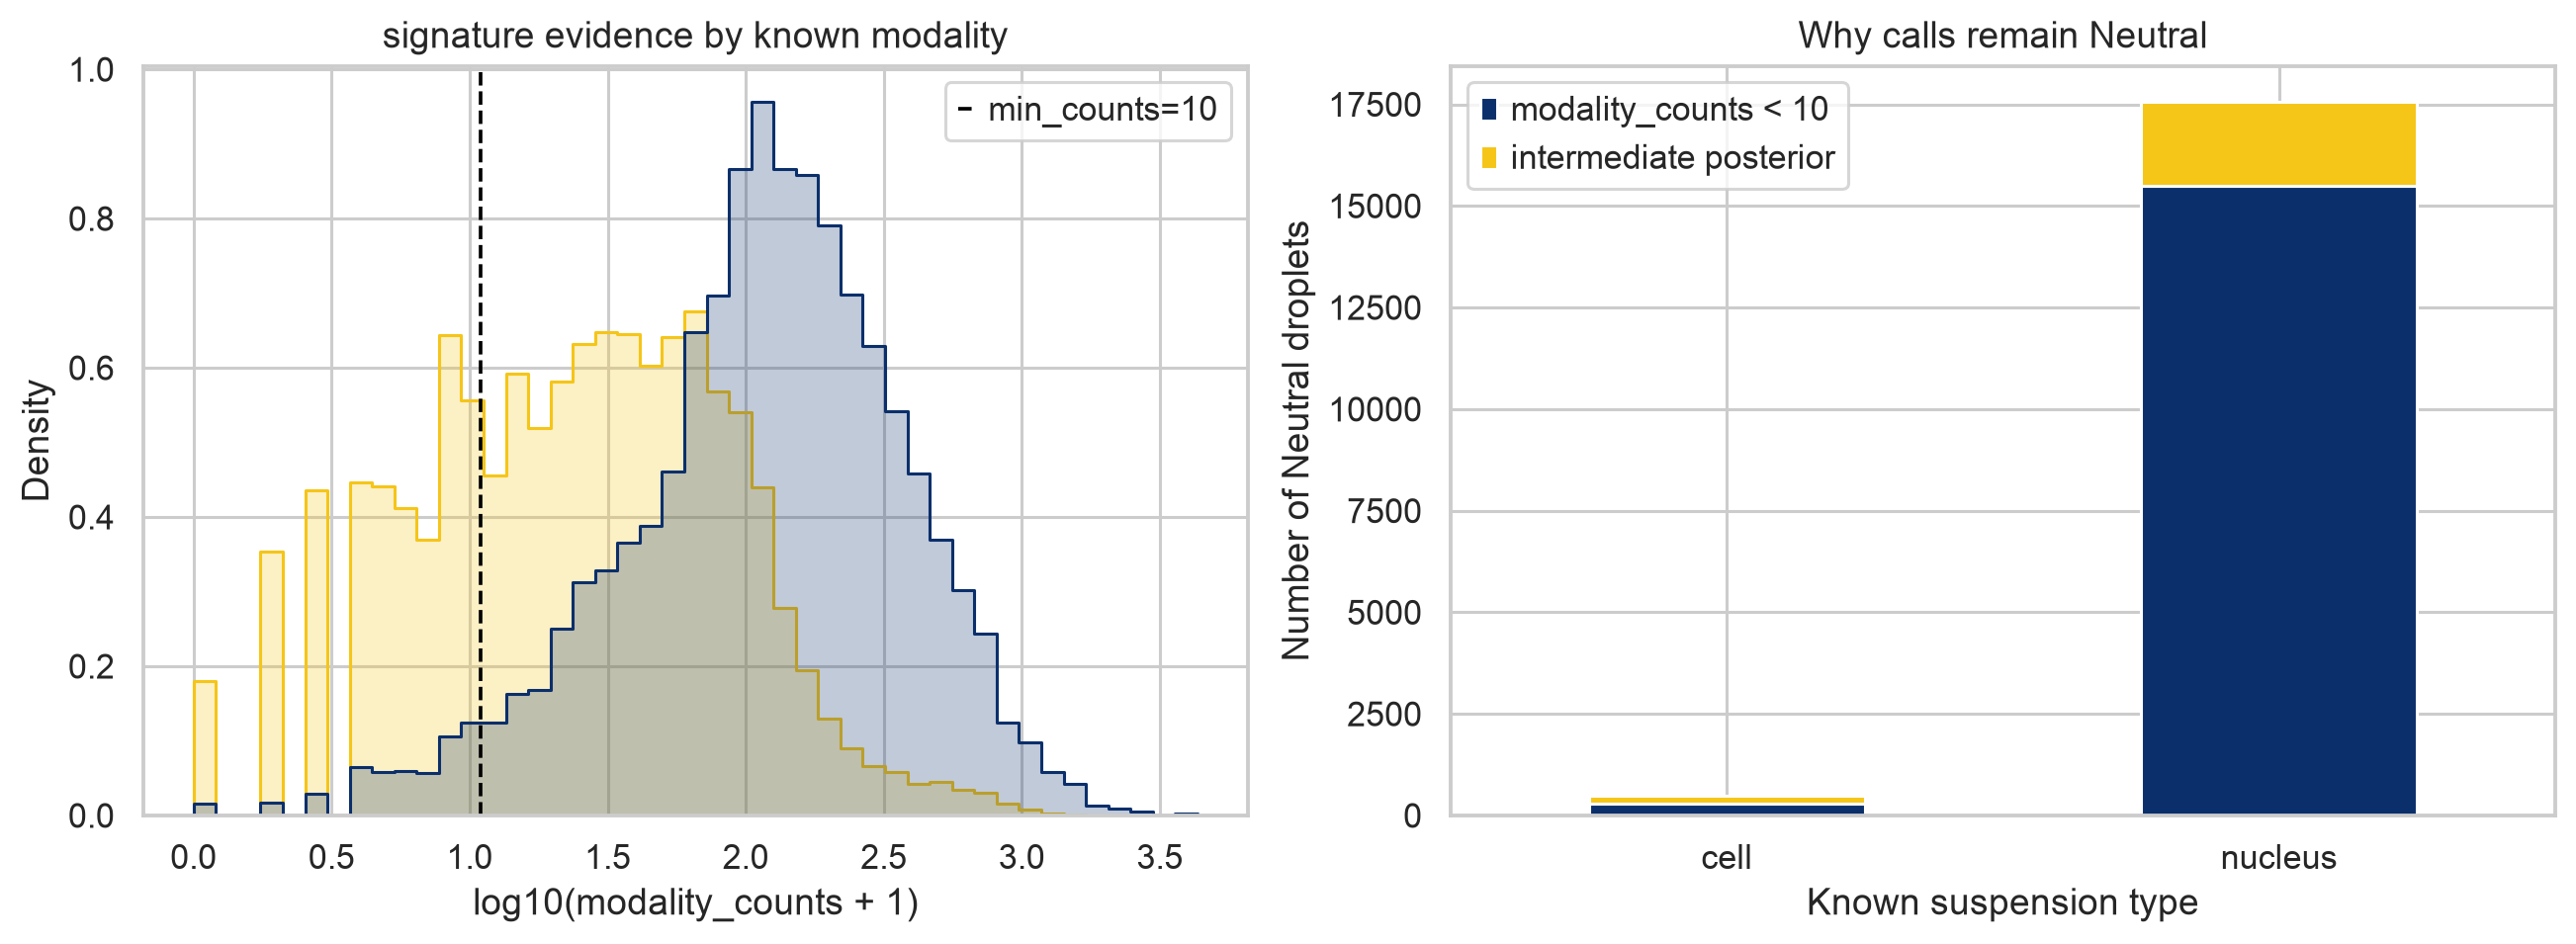

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

q1_plot = q1.obs[["suspension_type", "modality_counts"]].copy()
q1_plot["log10_modality_counts_plus_1"] = np.log10(q1_plot["modality_counts"] + 1)

palette = {"cell": "#0A2F6B", "nucleus": "#F5C518"}
sns.histplot(
    data=q1_plot,
    x="log10_modality_counts_plus_1",
    hue="suspension_type",
    palette=palette,
    bins=45,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[0],
)

axes[0].axvline(
    np.log10(10 + 1), # keeps m=0 on the axis; log10(11)=1.04
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="min_counts=10",
)
axes[0].set_title("signature evidence by known modality")
axes[0].set_xlabel("log10(modality_counts + 1)")
axes[0].legend(title=None)

source_order = ["modality_counts < 10", "intermediate posterior"]
neutral_plot = q1_neutral_sources.reindex(columns=source_order, fill_value=0)
neutral_plot.plot(
    kind="bar",
    stacked=True,
    color=["#0A2F6B", "#F5C518"],
    ax=axes[1],
)
axes[1].set_title("Why calls remain Neutral")
axes[1].set_xlabel("Known suspension type")
axes[1].set_ylabel("Number of Neutral droplets")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title=None)

plt.tight_layout()
plt.show()

Decision rules in the source code reveal the origin of Neutral calls. 

One is the insufficient modality count. Droplets with `modality_count<10`, accounting for most of the Neutral calls, cannot receive an evidence-based cell-like or nucleus-like label, regardless of their posterior. This is a deliberate low-evidence abstention (since the confidence of 9/10 is different from 900/1000). 

The other is an intermediate posterior. The remaining Neutral droplets (sitting right of the dotted line) have enough counts but are assigned Neutral because of the $0.05 \leq p_{\text{cell}} \leq 0.95$ threshold. This might reflect some overlapping of mixed droplets or cell-type-specific expression pattern, but the CellorNucEM classifier alone cannot identify the biologically plausible reasons for Neutral calls.  

## Q2. Run on the single-modality dataset B (sc only)

**Many real projects have only sc (or only sn) data. There, the classifier is used to find droplets of the "other kind" that slipped in -- for example, droplets in an sc library whose cytoplasm lysed, leaving only the nucleus.** 

In [44]:
single = sc.read_h5ad(ROOT / "data" / "single_KidneyRaji_sc_full.h5ad")

### 2a

**Load dataset B and run CellorNucEM. What fraction of droplets are Nucleus-like Cell (SC)?**

In [45]:
q2_input = single.copy()
q2_input.obs["modality"] = "sc"

q2 = Scanpyplus.CellorNucEM(
    q2_input,
    sc_genes,
    sn_genes,
    assay_col="modality",
    layer="counts",
    min_counts=10,
    copy=True,
    gamma_hi=0.95,
    gamma_lo=0.05,
    init="anchored",
    max_p_nuc=0.2,
    min_p_cell=0.8,
    print_mode=False,
)

In [46]:
q2_counts = q2.obs["modality_classification"].value_counts()
q2_frac = q2_counts / q2.n_obs
print("Classification summary:")
display(pd.concat([q2_counts.rename("count"), q2_frac.rename("fraction")], axis=1))

Classification summary:


,count,fraction
modality_classification,,
Typical Cell (SC),116406,0.972262
Nucleus-like Cell (SC),3321,0.027738


The result is clearly shown in the table above. $2.77 \%$ droplets are Nucleus-like Cell. However, this does not necessarily mean the exact percentage of Nucleus-Like droplets. According to the source code

```python
neutral = (labels == "Neutral") & own
labels[neutral] = typical
```

there is a fallback rule for single-modality datasets. For this sc-only case, "typical" refers to "Typical Cell (SC)". So Neutral sc droplets (either because of `modality_counts < 10` or `0.05 <= p_cell <= 0.95`) are reassigned to Typical Cell. In other words, only droplets satisfying m>=10 and p_cell<0.05 are classified as Nucleus-like, and evrything else fall into the category of Typical Cell (SC). 

In [47]:
enough = q2.obs["modality_counts"] >= 10
confident_cell = enough & (q2.obs["p_cell"] > 0.95)
confident_nuc = enough & (q2.obs["p_cell"] < 0.05)
fallback = ~(confident_cell | confident_nuc)

print("Confident cell-like:", confident_cell.sum())
print("Nucleus-like:", confident_nuc.sum())
print("Fallback to Typical Cell:", fallback.sum())

Confident cell-like: 91999
Nucleus-like: 3321
Fallback to Typical Cell: 24407


The calculation above, especially the "Fallback to Typical Cell", supports the explanation. 

### 2b

**Plot a histogram of `sc_frac`. Is it unimodal or bimodal?**

undefined sc_frac (modality_counts = 0): 589


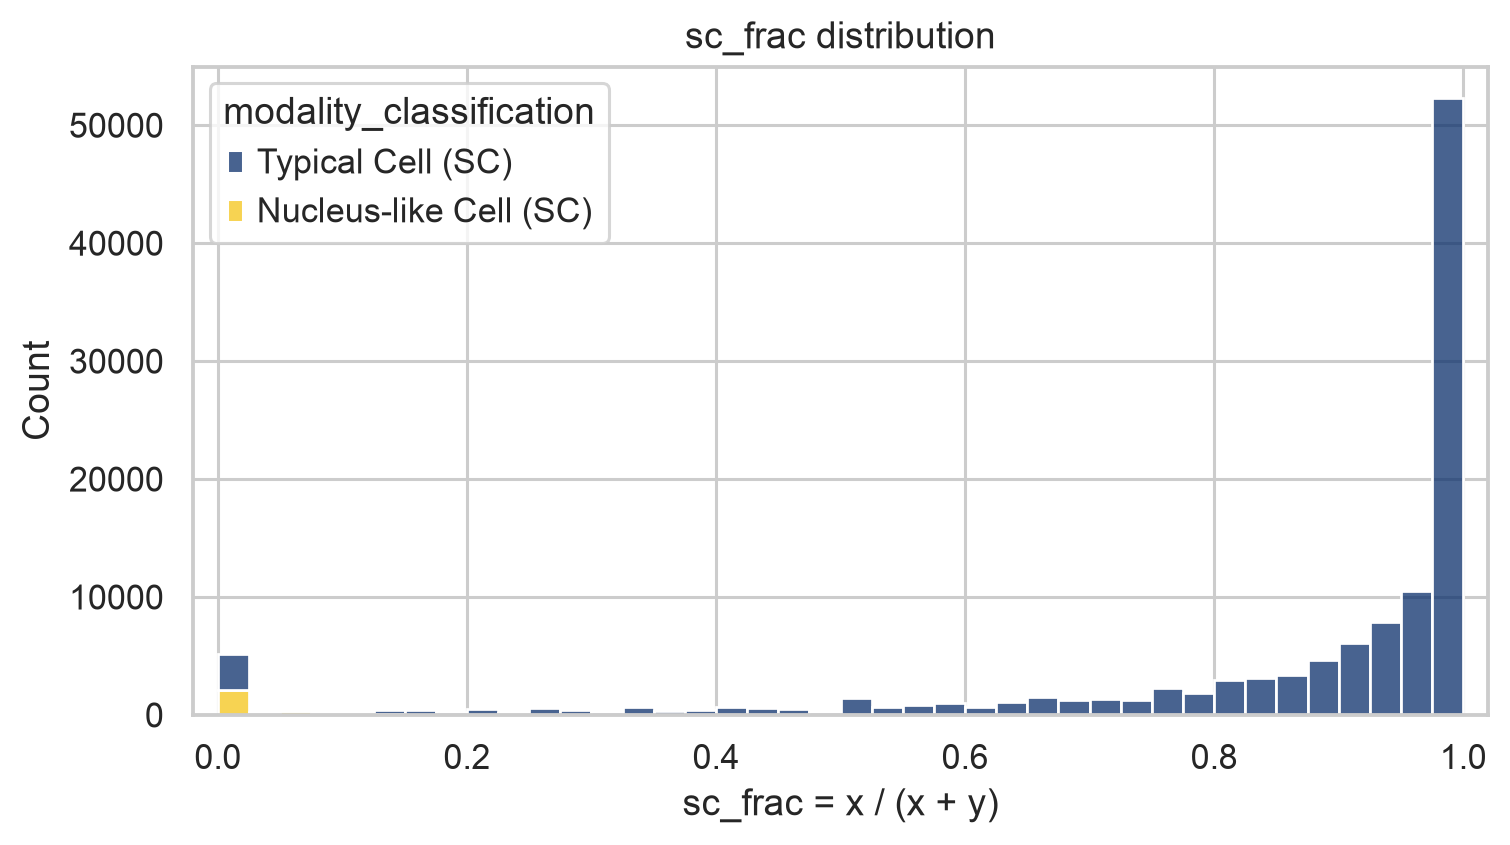

In [48]:
print("undefined sc_frac (modality_counts = 0):", int(q2.obs["sc_frac"].isna().sum()))

fig, ax = plt.subplots(figsize=(7, 4))
palette = {"Nucleus-like Cell (SC)": "#F5C518", "Typical Cell (SC)": "#0A2F6B"}
q2_plot = q2.obs[["sc_frac", "modality_classification"]].copy()
sns.histplot(
    data=q2_plot,
    x="sc_frac",
    hue="modality_classification",
    palette=palette,
    bins=np.linspace(0, 1, 41),
    multiple="stack",
    ax=ax,
)
ax.set_title("sc_frac distribution")
ax.set_xlim(-0.02, 1.02)
ax.set_xlabel("sc_frac = x / (x + y)")
plt.tight_layout()
plt.show()

How to tell whether it is unimodal or bimodal? Read it from the histogram!

A dominant pile near 1 plus a distinct pile near 0 means it is bimodal, even if the low pile is much smaller. Maybe we should call it the "imbalanced bimodality"?

In [49]:
valid_sc_frac = q2.obs["sc_frac"].dropna()
bin_edges = np.linspace(0, 1, 41)

bin_counts, _ = np.histogram(valid_sc_frac, bins=bin_edges)

sc_frac_bins = pd.DataFrame({
    "bin_left": bin_edges[:-1],
    "bin_right": bin_edges[1:],
    "count": bin_counts,
})

sc_frac_bins["percent"] = (
    100 * sc_frac_bins["count"] / len(valid_sc_frac)
)

display(sc_frac_bins)

,bin_left,bin_right,count,percent
0,0.000,0.025,5196,4.361329
1,0.025,0.050,283,0.237540
2,0.050,0.075,351,0.294616
3,0.075,0.100,333,0.279508
4,0.100,0.125,354,0.297134
5,0.125,0.150,432,0.362605
6,0.150,0.175,381,0.319797
7,0.175,0.200,253,0.212359
8,0.200,0.225,475,0.398697
9,0.225,0.250,202,0.169551


For a more reliable interpretation, we investigate into all 40 bins. And this verifies our bimodal conclusion. 

The dominant rightmost bin contains 52350 droplets, while a smaller local peak occurs in the leftmost bin containing 5196 droplets, compared with only 283, 351, and 333 droplets in the next three bins. The sharp drop after the leftmost bin supports interpreting it as a secondary mode rather than merely the end of a smooth tail. 

## Q3: Anchor vs. Split

**CellorNucEM has an "anchor" related mechanism.**

### 3a

**On dataset B, run (i) the default parameters; `init="anchored"`, (ii) `init="split"`. Compare the two component means $p$ between the two fits. Are the differences large? If yes, what could be the reasons?**

In [50]:
def component_means(adata):
    fit = adata.uns["modality_em"]["global"]
    a_cell, b_cell = fit["ab_cell"]
    a_nuc, b_nuc = fit["ab_nuc"]
    return pd.Series(
        {
            "p_cell_component": a_cell / (a_cell + b_cell),
            "p_nuc_component": a_nuc / (a_nuc + b_nuc),
        }
    )

q3a = {}
for init in ("anchored", "split"):
    fitted = Scanpyplus.CellorNucEM(
        single, sc_genes, sn_genes, layer="counts", init=init, copy=True, print_mode=False
    )
    q3a[init] = component_means(fitted)

q3a = pd.DataFrame(q3a).T
q3a.loc["abs_diff"] = (q3a.loc["anchored"] - q3a.loc["split"]).abs()
q3a

,p_cell_component,p_nuc_component
anchored,0.920773,0.388908
split,0.923955,0.640799
abs_diff,0.003182,0.251891


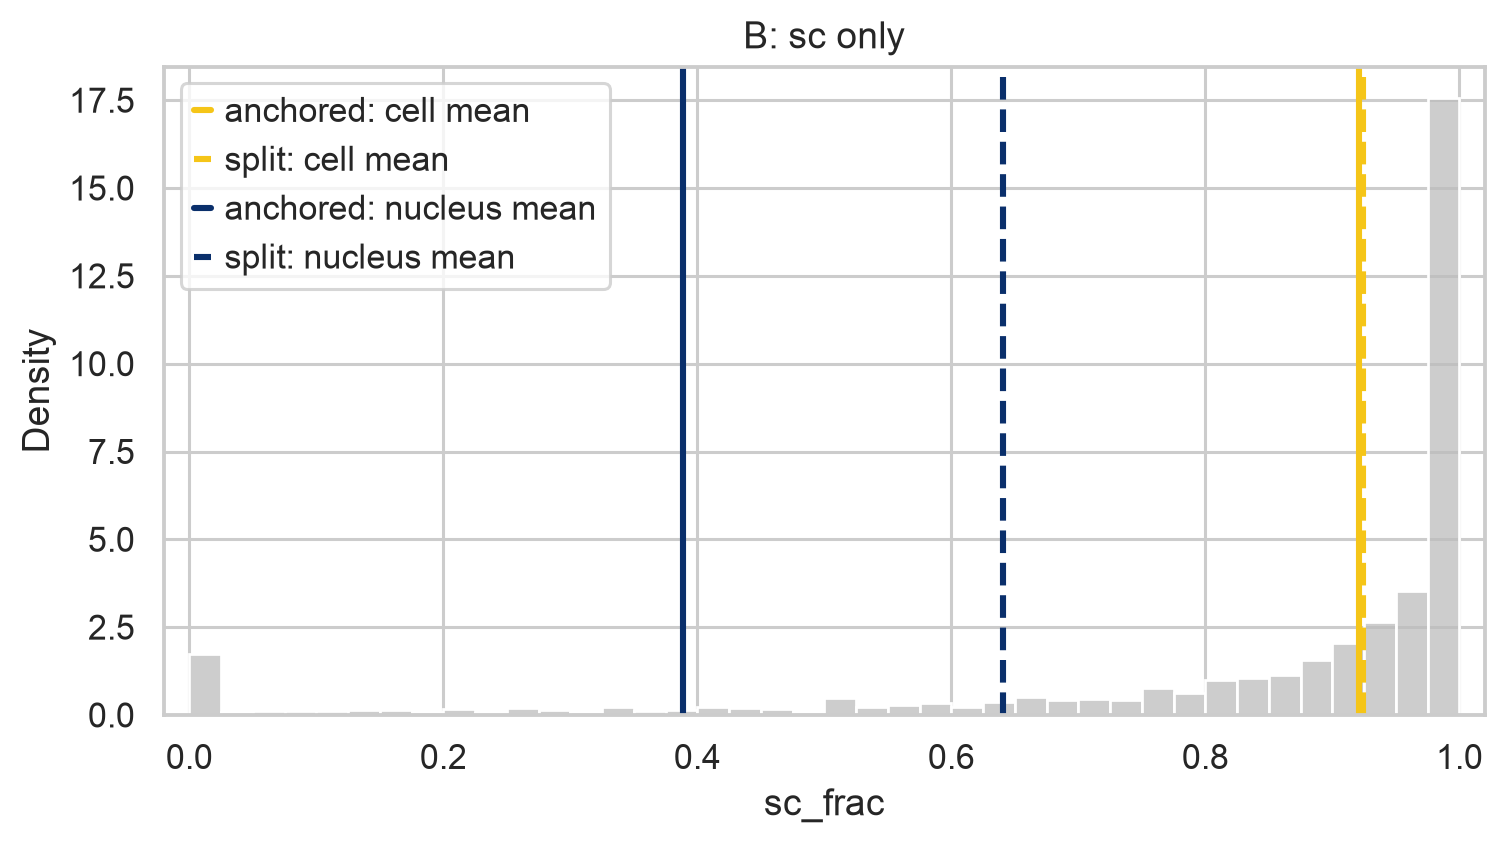

In [51]:
def plot_component_means(sc_frac, means, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.histplot(
        sc_frac.dropna(),
        bins=np.linspace(0, 1, 41),
        stat="density",
        color="#bdbdbd",
        ax=ax,
    )
    ax.axvline(means.loc["anchored", "p_cell_component"], color="#F5C518", ls="-", lw=2, label="anchored: cell mean")
    ax.axvline(means.loc["split", "p_cell_component"], color="#F5C518", ls="--", lw=2, label="split: cell mean")
    ax.axvline(means.loc["anchored", "p_nuc_component"], color="#0A2F6B", ls="-", lw=2, label="anchored: nucleus mean")
    ax.axvline(means.loc["split", "p_nuc_component"], color="#0A2F6B", ls="--", lw=2, label="split: nucleus mean")
    ax.set_xlim(-0.02, 1.02)
    ax.set_xlabel("sc_frac")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_component_means(q2.obs["sc_frac"], q3a, "B: sc only")


Numerical comparisons are shown in the table above, and we can see (both from the numbers and the plots) that the cell-component means harly differ, while the nucleus-component means differ by approximately 0.25, which is large o a 0-1 scale.

The main reason behind this phenomenon might be the EM algorithm's sensitivity to initialization. The nucleus component is the minority in an sc-only dataset and is much less identifiable. `init="split"` initializes by cutting at the evidence-weighted mean $\sum x_i / \sum m_i$, which can divide the broad dominant population; while `anchored` seeds the nucleus component from cells with p < anchor_lo (0.3) and the cell component from p > anchor_hi (0.7). Since mixture likelihoods have local optima, the starting points can lead to different decompositions. More specifically, as the docstring of `_fit_two_comp_EM` explains, the weightd mean where the "split" scheme cuts falls inside the major peak, and EM then converges to some solution that splits the majority peak into two. 

### 3b

**Switch to dataset A: take only droplets with `suspension_type=="cell"` and compare (i) and (ii) in the same way; then do the same with nucleus only.**

,p_cell_component,p_nuc_component
anchored,0.972187,0.621174
split,0.973697,0.847522
abs_diff,0.001510,0.226348


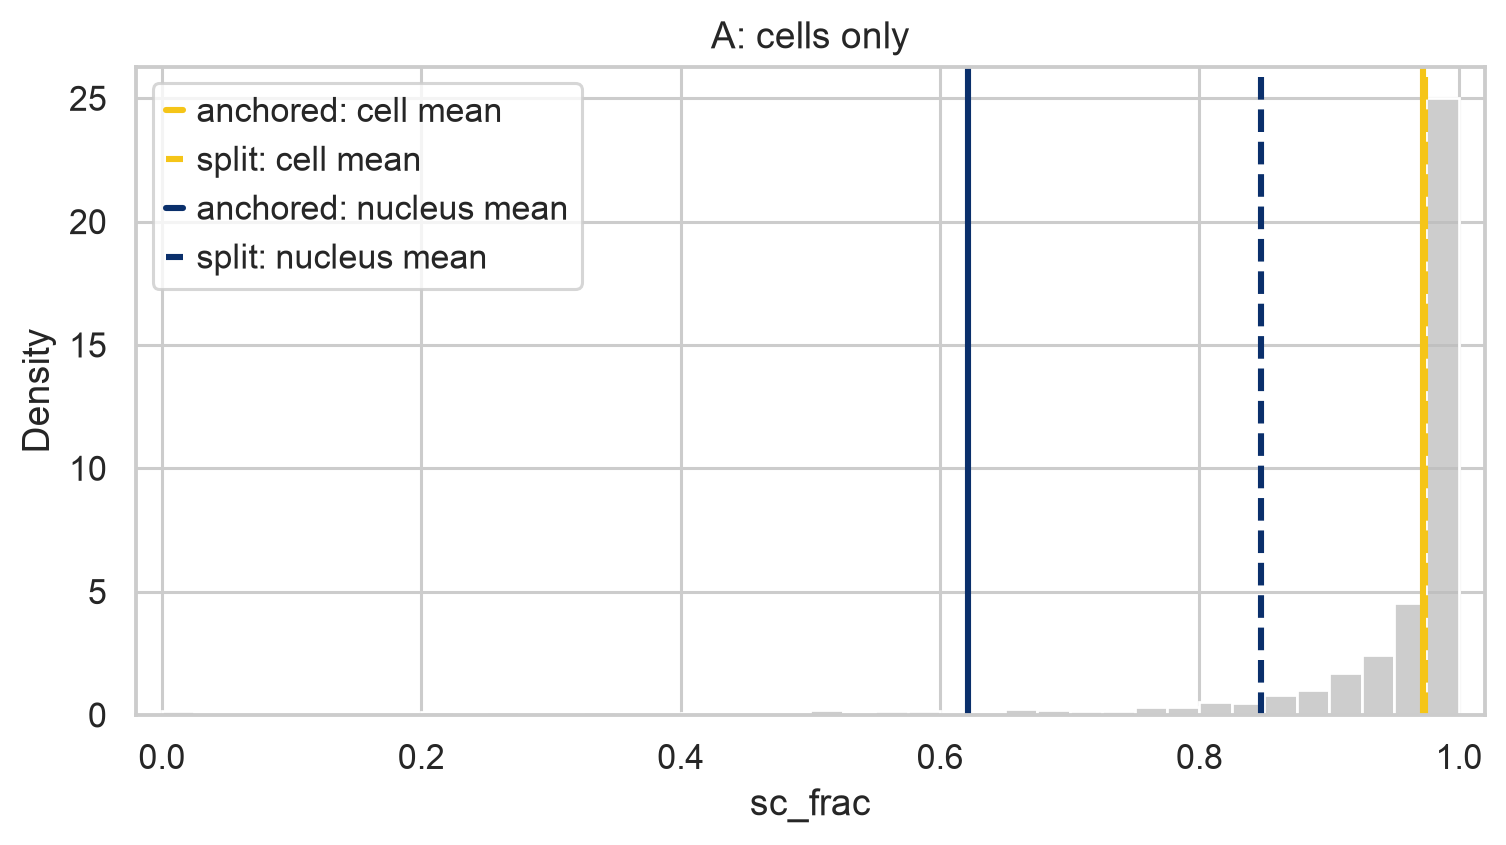

In [52]:
q3b_cells = {}
q3b_cells_sc_frac = None
for init in ("anchored", "split"):
    fitted = Scanpyplus.CellorNucEM(
        mixed[mixed.obs["suspension_type"] == "cell"],
        sc_genes,
        sn_genes,
        layer="counts",
        init=init,
        copy=True,
        print_mode=False,
    )
    q3b_cells[init] = component_means(fitted)
    if q3b_cells_sc_frac is None:
        q3b_cells_sc_frac = fitted.obs["sc_frac"].copy()

q3b_cells = pd.DataFrame(q3b_cells).T
q3b_cells.loc["abs_diff"] = (q3b_cells.loc["anchored"] - q3b_cells.loc["split"]).abs()
display(q3b_cells)
plot_component_means(q3b_cells_sc_frac, q3b_cells, "A: cells only")


,p_cell_component,p_nuc_component
anchored,0.348013,0.079533
split,0.172021,0.068768
abs_diff,0.175992,0.010765


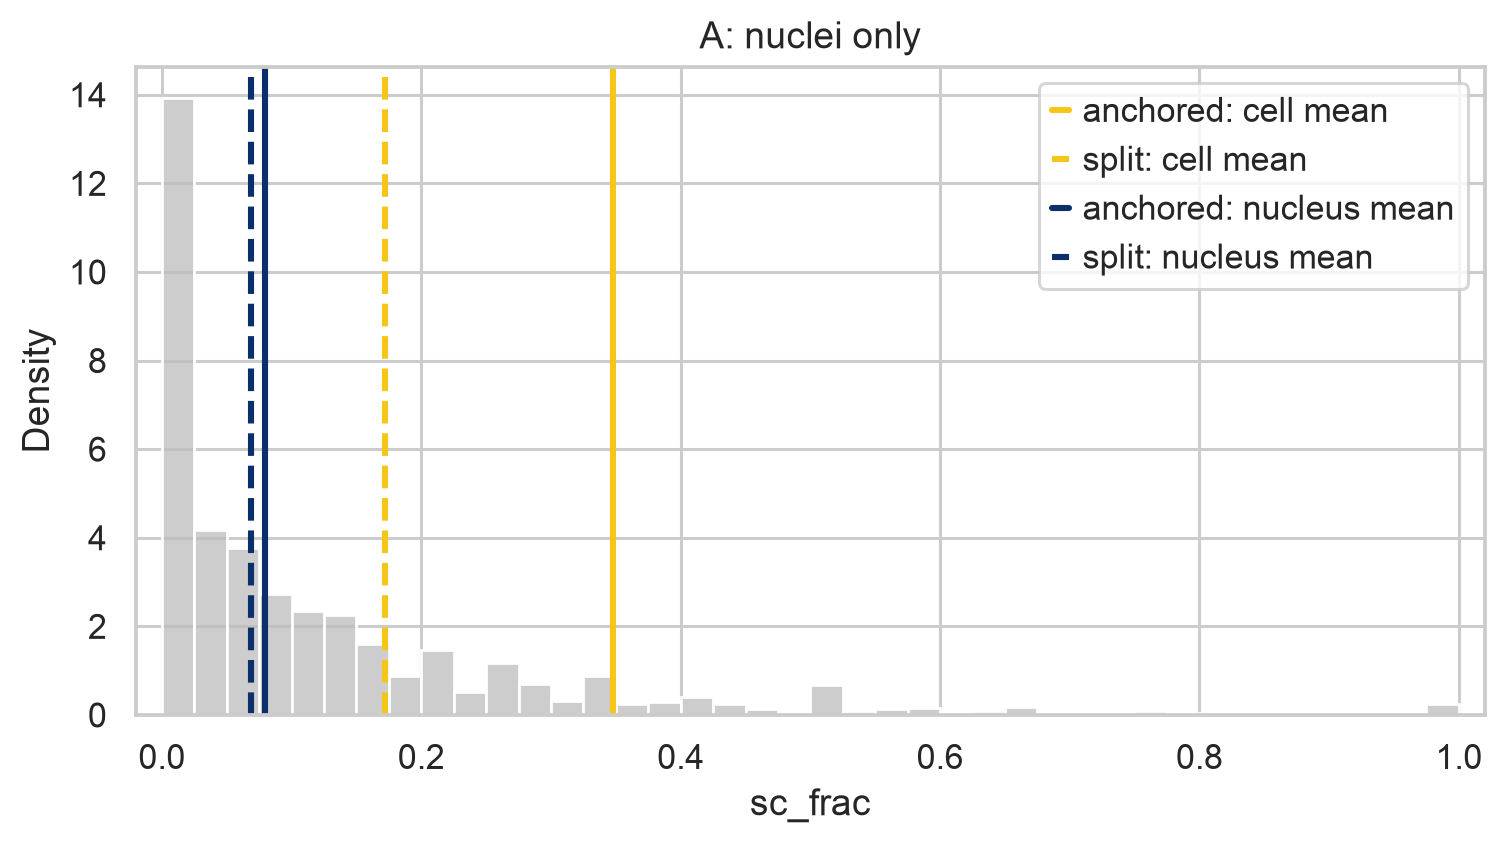

In [53]:
q3b_nuclei = {}
q3b_nuclei_sc_frac = None
for init in ("anchored", "split"):
    fitted = Scanpyplus.CellorNucEM(
        mixed[mixed.obs["suspension_type"] == "nucleus"],
        sc_genes,
        sn_genes,
        layer="counts",
        init=init,
        copy=True,
        print_mode=False,
    )
    q3b_nuclei[init] = component_means(fitted)
    if q3b_nuclei_sc_frac is None:
        q3b_nuclei_sc_frac = fitted.obs["sc_frac"].copy()

q3b_nuclei = pd.DataFrame(q3b_nuclei).T
q3b_nuclei.loc["abs_diff"] = (q3b_nuclei.loc["anchored"] - q3b_nuclei.loc["split"]).abs()
display(q3b_nuclei)
plot_component_means(q3b_nuclei_sc_frac, q3b_nuclei, "A: nuclei only")


Seems like control experiments for testing and verifying the conclusion drawn in 3a. Therefore, separating the mixed dataset A into cells-only and nuclei-only subsets here makes sense! 

Similarly, we cna interpret from the numbers and figures that the component mean of the minority component differ greatly when initializaiton method changes. For known cells-only, the dominant cell mean changes by only 0.0015, whereas the nucleus mean changes by 0.2263. For known nuclei only, the dominant nucleus mean changes by 0.0107, while the cell mean changes by 0.1760. 

The symmetric result supports the interpretation in 3a.

Looking back on 3a and 3b together, we can see that the same pattern keeps appearing in single-modality sets, where the compoment matching the observed majority modality is stable, while the absent or rare opposite component is sensitive to initialization. This is therefore a general single-modality fitting issue rather than a peculiarity of dataset B. 

Thus, the `anchor` mainly stablize the starting interpretation of the minority component (though they only serve as initialization rules and the actual hard constraints during EM iteration process are `max_p_nuc` and `min_p_cell`). 

## Bonus: Cell Identity and Classifier Scores

**If you have additional time and would like to explore the data further, you may annotate the cell types, examine the relationship between cell identity and the cell/nucleus scores generated by the classifier, and consider possible biological or technical explanations for any cell-type-specific patterns you observe.**

The datasets already contain author-provided biological labels, so no new clustering or annotation is needed. (Or did I misinterpret "you may annotate the cell types"?) Clustering may identify expression-similar groups, but it does not by itself assign biological identity. Here below are what I found in the original datasets:

In [54]:
inventory = pd.DataFrame(
    [
        ["A: mixed", "broad_cell_type", q1.obs["broad_cell_type"].nunique()],
        ["A: mixed", "cell_type", q1.obs["cell_type"].nunique()],
        ["B: sc-only", "reannotated_celltype", q2.obs["reannotated_celltype"].nunique()],
        ["B: sc-only", "Predicted", q2.obs["Predicted"].nunique()],
        ["B: sc-only", "leiden (cluster, not annotation)", q2.obs["leiden"].nunique()],
    ],
    columns=["dataset", "column", "number_of_labels"],
)
inventory

,dataset,column,number_of_labels
0,A: mixed,broad_cell_type,12
1,A: mixed,cell_type,35
2,B: sc-only,reannotated_celltype,86
3,B: sc-only,Predicted,72
4,B: sc-only,"leiden (cluster, not annotation)",41


### Analysis on dataset B

Since dataset B is sc-only, we start from here. 

In [55]:
bonus_b = q2.obs.copy()
bonus_b["cell_identity"] = bonus_b["reannotated_celltype"].astype("string").fillna("Unannotated")
bonus_b["nucleus_like"] = bonus_b["modality_classification"].astype(str).eq("Nucleus-like Cell (SC)")
bonus_b["below_min_counts"] = bonus_b["modality_counts"].lt(10)

bonus_b_summary = (
    bonus_b.groupby("cell_identity", observed=True)
    .agg(
        n=("p_cell", "size"), # number of droplets
        nucleus_like_n=("nucleus_like", "sum"),
        median_p_cell=("p_cell", "median"),
        median_modality_counts=("modality_counts", "median"),
        below_min_counts_rate=("below_min_counts", "mean")
    )
)
bonus_b_summary["nucleus_like_rate"] = bonus_b_summary["nucleus_like_n"] / bonus_b_summary["n"]
bonus_b_ranked = bonus_b_summary.query("n >= 20").sort_values(
    ["nucleus_like_rate", "n"], ascending=[False, False]
)

print(f"Overall Nucleus-like rate: {bonus_b['nucleus_like'].mean():.2%}")
display(
    bonus_b_ranked[
        ["n", "nucleus_like_n", "nucleus_like_rate", "median_p_cell",
         "median_modality_counts", "below_min_counts_rate"]
    ].head(15).style.format(
        {
            "nucleus_like_rate": "{:.1%}",
            "median_p_cell": "{:.3f}",
            "median_modality_counts": "{:.1f}",
            "below_min_counts_rate": "{:.1%}",
        }
    )
)

Overall Nucleus-like rate: 2.77%


,n,nucleus_like_n,nucleus_like_rate,median_p_cell,median_modality_counts,below_min_counts_rate
cell_identity,,,,,,
CCD-PC|CNT doub,361,222,61.5%,0.009,20.0,17.7%
DTL3,184,77,41.8%,0.036,18.0,23.9%
POD,337,141,41.8%,0.131,91.0,0.9%
CCD-PC,1179,455,38.6%,0.057,15.0,31.4%
PT-S3,204,47,23.0%,0.532,62.0,1.0%
PCDH15+ aPT,448,83,18.5%,0.965,106.0,2.7%
aPT,3667,555,15.1%,0.987,82.0,3.1%
DTL2,1523,211,13.9%,0.920,41.0,8.3%
PEC,1352,140,10.4%,0.996,49.0,7.4%


Cell identity and classifier scores do associate. 

We can see from the table above that the $2.77\%$ Nucleus-like rate is not spread evenly across different cell types. A few identities such as CCD-PS?CNT doub, DLT3, and POD are high above the global rate, while most common types sit near it. To identify identity-specific patterns, we may look at those with **enough modality counts** but still display a **high nucleus-like rate**. Take **POD** as an example. The model has plenty of $m$ but still puts many droplets in the low component, indicating soem nucleus-like signature composition. But further explanation is beyond what this table can tell and might relate to experimental operations or biological charateristics, which I currently cannot explain. 

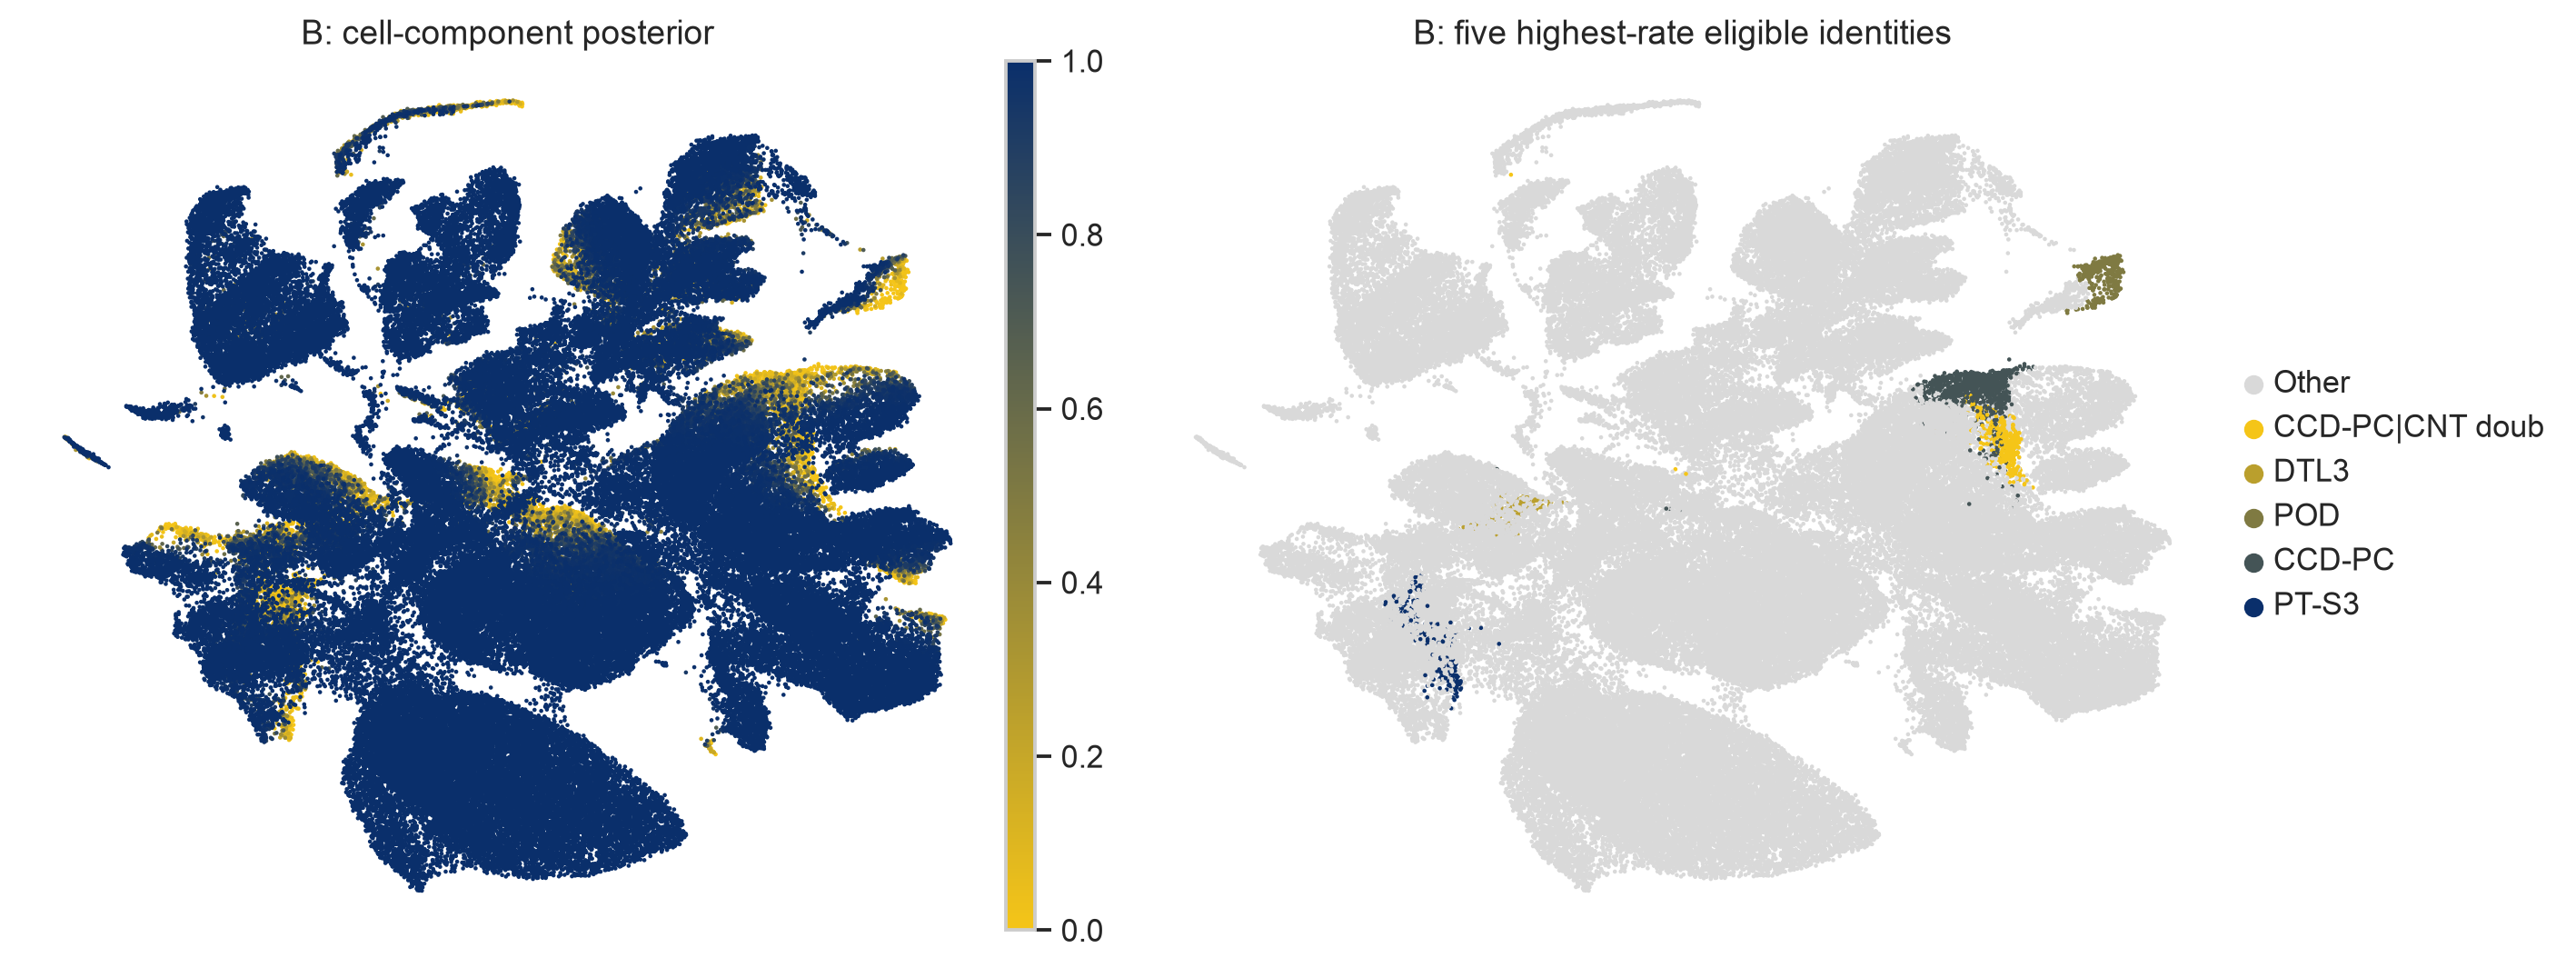

In [56]:
top_b_types = bonus_b_ranked.head(5).index.tolist()
q2.obs["bonus_top_identity"] = np.where(
    q2.obs["reannotated_celltype"].astype("string").isin(top_b_types),
    q2.obs["reannotated_celltype"].astype("string"),
    "Other",
)
q2.obs["bonus_top_identity"] = pd.Categorical(
    q2.obs["bonus_top_identity"], categories=["Other", *top_b_types]
)

berkeley_cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "berkeley", ["#F5C518", "#0A2F6B"]
)
top_colors = [
    plt.matplotlib.colors.to_hex(berkeley_cmap(x))
    for x in np.linspace(0, 1, len(top_b_types))
]
identity_palette = {"Other": "#d9d9d9", **dict(zip(top_b_types, top_colors))}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(
    q2, color="p_cell", cmap=berkeley_cmap, vmin=0, vmax=1,
    size=9, ax=axes[0], show=False, frameon=False,
    title="B: cell-component posterior",
)
sc.pl.umap(
    q2, color="bonus_top_identity", palette=identity_palette,
    size=9, ax=axes[1], show=False, frameon=False,
    title="B: five highest-rate eligible identities",
)
plt.tight_layout()
plt.show()

### Analysis on dataset A

In [57]:
bonus_a = q1.obs.copy()
bonus_a["cell_identity"] = bonus_a["broad_cell_type"].astype("string").fillna("Unannotated")
bonus_a["source"] = bonus_a["suspension_type"].astype("string")
bonus_a["neutral"] = bonus_a["modality_classification"].astype(str).eq("Neutral")
bonus_a["below_min_counts"] = bonus_a["modality_counts"].lt(10)
bonus_a["discordant"] = np.where(
    bonus_a["source"].eq("cell"),
    bonus_a["modality_classification"].astype(str).eq("Nucleus-like Cell (SC)"),
    bonus_a["modality_classification"].astype(str).eq("Cell-like Nucleus (SN)"),
)

bonus_a_summary = (
    bonus_a.groupby(["source", "cell_identity"], observed=True)
    .agg(
        n=("p_cell", "size"),
        neutral_n=("neutral", "sum"),
        discordant_n=("discordant", "sum"),
        median_modality_counts=("modality_counts", "median"),
        below_min_counts_rate=("below_min_counts", "mean"),
    )
    .reset_index()
)
bonus_a_summary["neutral_rate"] = bonus_a_summary["neutral_n"] / bonus_a_summary["n"]
bonus_a_summary["discordant_rate"] = bonus_a_summary["discordant_n"] / bonus_a_summary["n"]

bonus_a_ranked = (
    bonus_a_summary.query("n >= 20")
    .sort_values(["source", "neutral_rate", "n"], ascending=[True, False, False])
)
bonus_a_display = bonus_a_ranked.groupby("source", observed=True).head(10)

display(
    bonus_a_display[
        ["source", "cell_identity", "n", "neutral_n", "neutral_rate",
         "discordant_rate", "median_modality_counts", "below_min_counts_rate"]
    ].style.format(
        {
            "neutral_rate": "{:.1%}",
            "discordant_rate": "{:.1%}",
            "median_modality_counts": "{:.1f}",
            "below_min_counts_rate": "{:.1%}",
        }
    )
)

,source,cell_identity,n,neutral_n,neutral_rate,discordant_rate,median_modality_counts,below_min_counts_rate
2,cell,Endothelial Cell,834,120,14.4%,1.2%,42.0,11.3%
8,cell,Principal Cell,456,60,13.2%,4.8%,89.0,2.0%
4,cell,Immune Cell,1431,172,12.0%,0.8%,95.0,10.8%
6,cell,Parietal Epithelial Cell,47,4,8.5%,6.4%,150.0,4.3%
7,cell,Podocyte,53,4,7.5%,15.1%,48.0,1.9%
0,cell,Connecting Tubule Cell,417,26,6.2%,2.4%,142.0,0.5%
10,cell,Thick Ascending Limb Cell,1035,54,5.2%,1.3%,132.0,1.3%
11,cell,Vascular Smooth Muscle Cell / Pericyte,389,16,4.1%,1.0%,99.0,2.3%
5,cell,Intercalated Cell,494,17,3.4%,1.8%,220.5,1.8%
1,cell,Distal Tubule Epithelial Cell,227,7,3.1%,3.5%,127.0,0.4%


On mixed dataset A, the classifier scores are not uniform across cell types even after splitting into cell and nucleus subsets. 

In cells, principal cells stay Neutral despite high $m$. In nuclei, most high Neutral types such as immune, endothelial, and fibroblast, do not have enough modality counts. Types with high Neutral or discordance and low "below_min_counts_rate" are the identity-score associations worth discussing. Again, some further biological interpretations are beyond my current capability. 

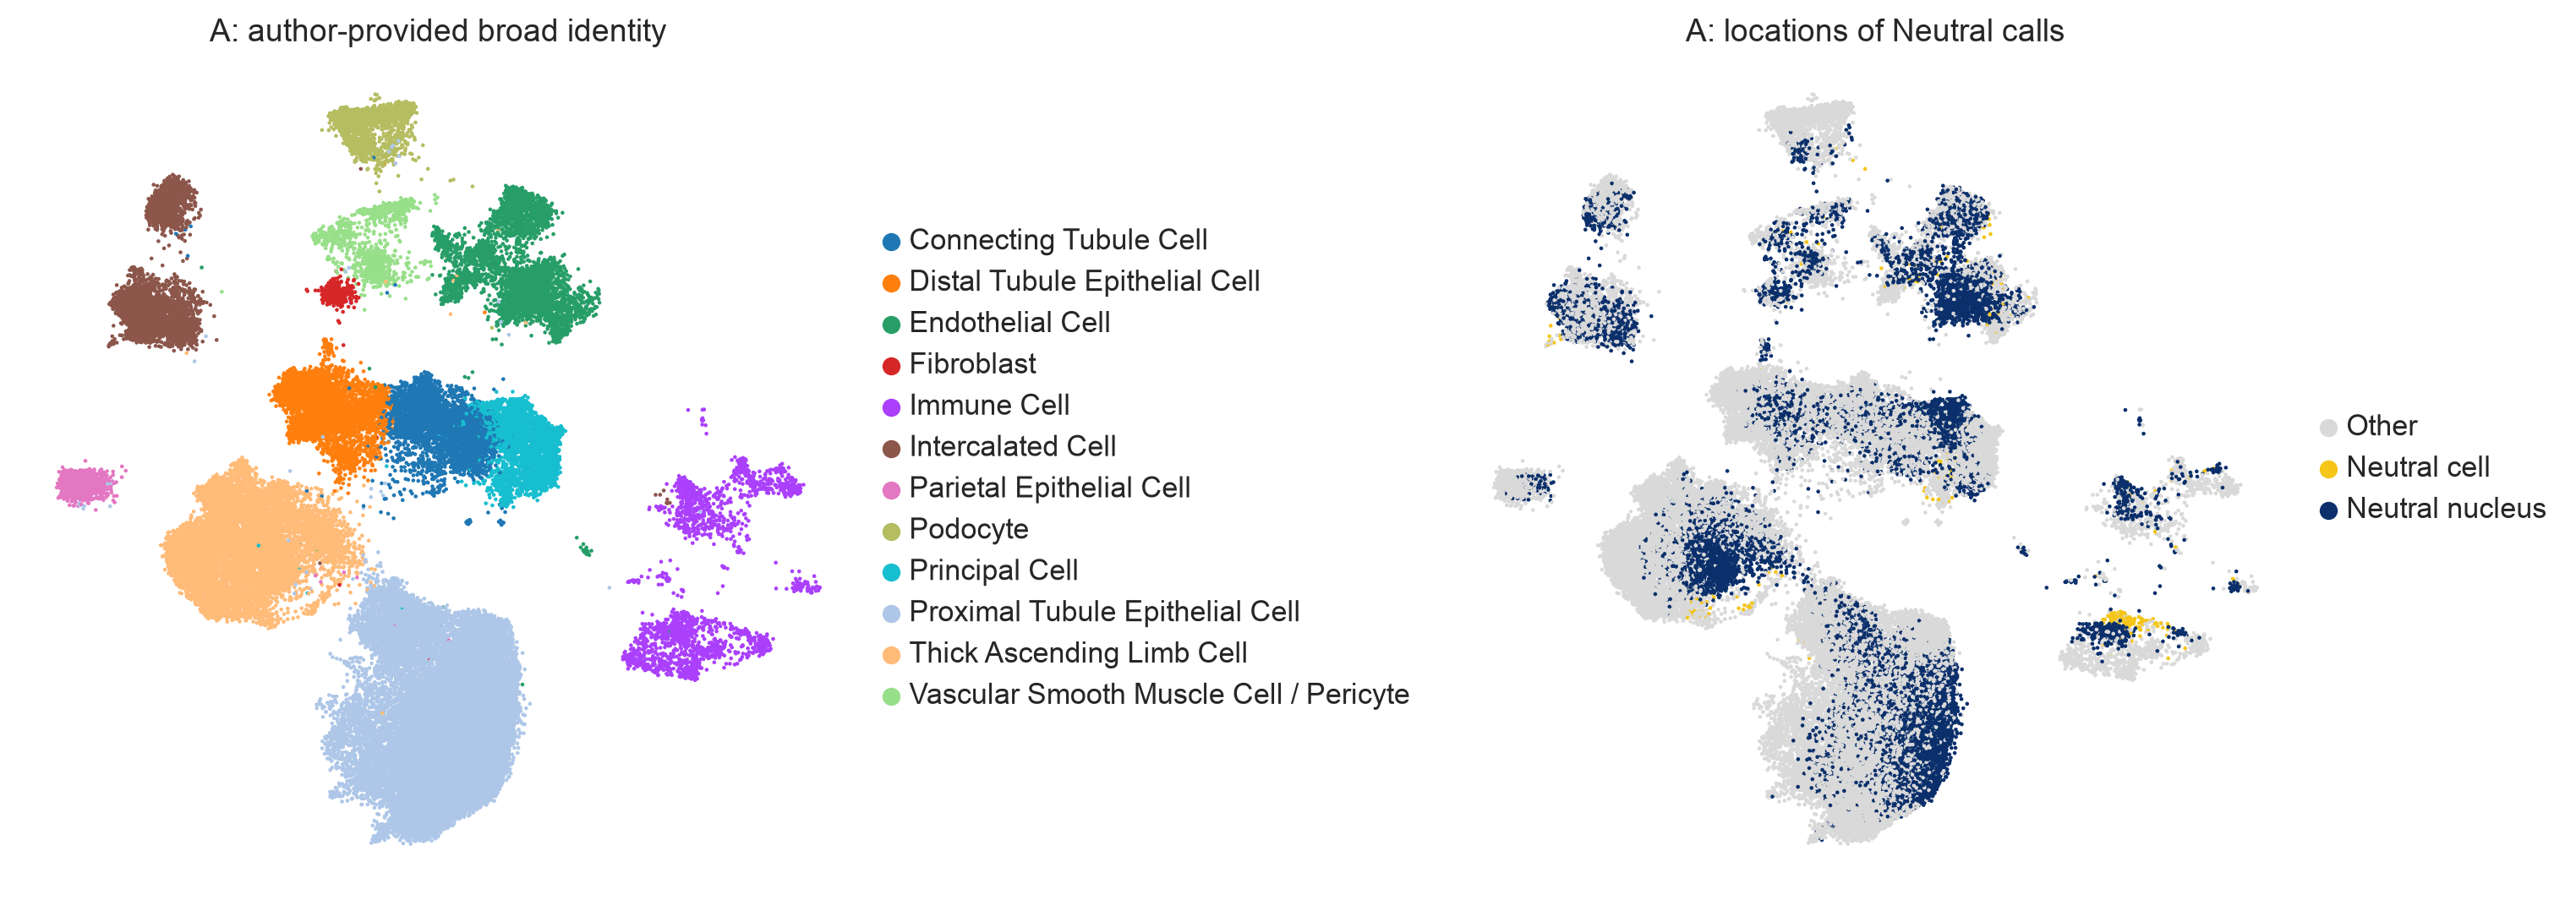

In [58]:
# Compare biological neighborhoods with the locations of Neutral calls.
q1.obs["bonus_neutral_source"] = np.select(
    [
        q1.obs["suspension_type"].astype(str).eq("cell")
        & q1.obs["modality_classification"].astype(str).eq("Neutral"),
        q1.obs["suspension_type"].astype(str).eq("nucleus")
        & q1.obs["modality_classification"].astype(str).eq("Neutral"),
    ],
    ["Neutral cell", "Neutral nucleus"],
    default="Other",
)
q1.obs["bonus_neutral_source"] = pd.Categorical(
    q1.obs["bonus_neutral_source"],
    categories=["Other", "Neutral cell", "Neutral nucleus"],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(
    q1, color="broad_cell_type", size=9,
    ax=axes[0], show=False, frameon=False,
    title="A: author-provided broad identity",
)
sc.pl.umap(
    q1, color="bonus_neutral_source",
    palette={"Other": "#d9d9d9", "Neutral cell": "#F5C518", "Neutral nucleus": "#0A2F6B"},
    size=9, ax=axes[1], show=False, frameon=False,
    title="A: locations of Neutral calls",
)
plt.tight_layout()
plt.show()

We can see from the UMAP visualization that Neutral calls on A concentrate in known nucleus neighbourhoods, especialy the immune/endothelial parts and the tuble clusters. 

## Conclusion and Reflection

`CellorNucEM` reduces each droplet to sc and sn signature counts. The sc signature count $x_i$ and sn-signature count $y_i$ define the total signature evidence $m_i=x_i+y_i$ and the observed fraction `sc_frac` ($x_i/m_i$). A two-component beta-binomial mixture models variation in this composition. Its fitted component means $p_k=\alpha_k/(\alpha_k+\beta_k)$ describe centers, whereas `p_cell` is the posterior probability that an individual droplet belongs to the high sc_frac component. Final labels additionally depend on `min_counts`, posterior thresholds, and possibly optional assay metadata.

The initialization experiments showed that the component representing the observed majority modality was stable, while the minority component was much more sensitive to initialization. Source reading also clarified that `anchor_lo` and `anchor_hi` determine starting values, whereas `max_p_nuc` and `min_p_cell` impose constraints. 

Finally, the bonus analysis showed that classifier behavior varies across supplied cell identities. These associations may reflect signature expression, experimental preparation, or some other reasons. They do not by themselves identify a biological mechanism, but may inspire further investigation into more reasons behind the phenomenon. 

In my adventure through this starter quiz, I first used the 6k subsets as a sandbox to understand the data structure, read the CellorNucEM source and its usage demo, and check that the analyses worked. Only then did I rerun the simplified pipeline on the full datasets used above. Q1-Q3 initially felt mostly like a coding/statistics exercise, understanding label semantics and EM initialization, but the bonus question changed how I viewed the problem by asking whether the computational patterns correspond to anything biologically meaningful. One small terminology surprise was that, coming from a math/CS background, I initially interpreted a "technical explanation" as something about the model itself or its implementation, but here the technical effects also begin upstream the data with experimental processes. I still do not have enough experience to distinguish the mechanisms confidently, so I treat the biological explanations as hypotheses rather than conclusions. But that seems to be exactly why combining model diagnostics with biological context is useful! 